## Generate Latent Clustermaps

This script is used to generate the heatmap clusters. Specifically after training a WTM on a set of samples, we wish to analyze what where the topic assigns each sample in the latent space.

In [2]:
import sys
sys.path.append('WTM')

import pickle as p
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

import new_ds
from new_ds import mm_Dataset
from WTM_model import WTM
from utils import calc_topic_uniqueness
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
pd.set_option('display.max_rows', None)
import pickle

import seaborn as sns
import time
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
def load_model(model_prefix, docSet):
    checkpoint = torch.load(f'WTM_checkpoints/{model_prefix}')
    param = checkpoint["param"]
    model = WTM(**param)
    model.load_model(checkpoint["net"])
    model.id2token = {v: k for k,v in docSet.dictionary.token2id.items()}
    return model

def get_embeds(model, docSet, labels_fname = None):
    embeds = model.get_embed(train_data=docSet, num=1000)

    if labels_fname:
        with open(labels_fname, 'r') as file:
            labels_list = [line.strip() for line in file.readlines()]
        out_df = pd.DataFrame(embeds, index=labels_list)
        return out_df
        
    return pd.DataFrame(embeds)

In [10]:
# get names of model checkpoints

ckpts_covid_t10_a5e2 = [f'covid_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]# best one!
ckpts_crc_t10_a5e2 = [f'crc_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]
ckpts_ibd_t10_a5e2 = [f'ibd_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]
ckpts_ibs_t10_a5e2 = [f'ibs_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]

ckpts_crc_log = [f'crc_tp10_a0.05_lr0.0005_log_nonorm/epoch_{i*25}.ckpt' for i in range(1, 21)]
ckpts_ibd_log = [f'ibd_tp10_a0.05_lr0.0005_log_nonorm/epoch_{i*25}.ckpt' for i in range(1, 21)]
ckpts_ibs_log = [f'ibs_tp10_a0.05_lr0.0005_log_nonorm/epoch_{i*25}.ckpt' for i in range(1, 21)]

ckpts_crc = [f'crc_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]
ckpts_ibd = [f'ibd_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]
ckpts_ibs = [f'ibs_model_tp10_a0.1_lr0.001/{i*10}.ckpt' for i in range(1, 11)]

In [6]:
#load expression data
covid_docSet = mm_Dataset(rebuild=True,
                        data_dir='/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu/privacy_network/covid_data',
                        mode_names=['gene', 'microbeR', 'premiR'],
                        expmat_fnames=['covid_gene.csv', 'covid_microbeR.csv', 'covid_premiR.csv'],
                        metadata_fname='covid_metadata.csv',
                        out_fname='covid_docDataset.pkl',
                        scale='gene'
                       )

crc_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu/privacy_network/crc_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['crc_gene.csv', 'crc_microbeR.csv'],
                        metadata_fname = 'crc_metadata.csv',
                        out_fname = 'crc_docDataset.pkl'
                       )

ibd_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu/privacy_network/ibd_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['ibd_gene.csv', 'ibd_microbeR.csv'],
                        metadata_fname = 'ibd_metadata.csv',
                        out_fname = 'ibd_docDataset.pkl')

ibs_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu/privacy_network/ibs_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['ibs_gene.csv', 'ibs_microbeR.csv'],
                        metadata_fname = 'ibs_metadata.csv',
                        out_fname = 'ibs_docDataset.pkl')

Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding


#### Getting HeatMap for COVID data

In [7]:
covid_docSet.samp_metadata['tissue'].value_counts()

tissue
BALF        56
Lung        23
PBMC         6
Heart        5
Liver        5
Placenta     5
Bowel        2
Jejunum      1
Kidney       1
Marrow       1
Name: count, dtype: int64

In [8]:
covid_docSet.samp_metadata['condition'].value_counts()

condition
SARS-CoV-2    62
Healthy       24
CAP           19
Name: count, dtype: int64

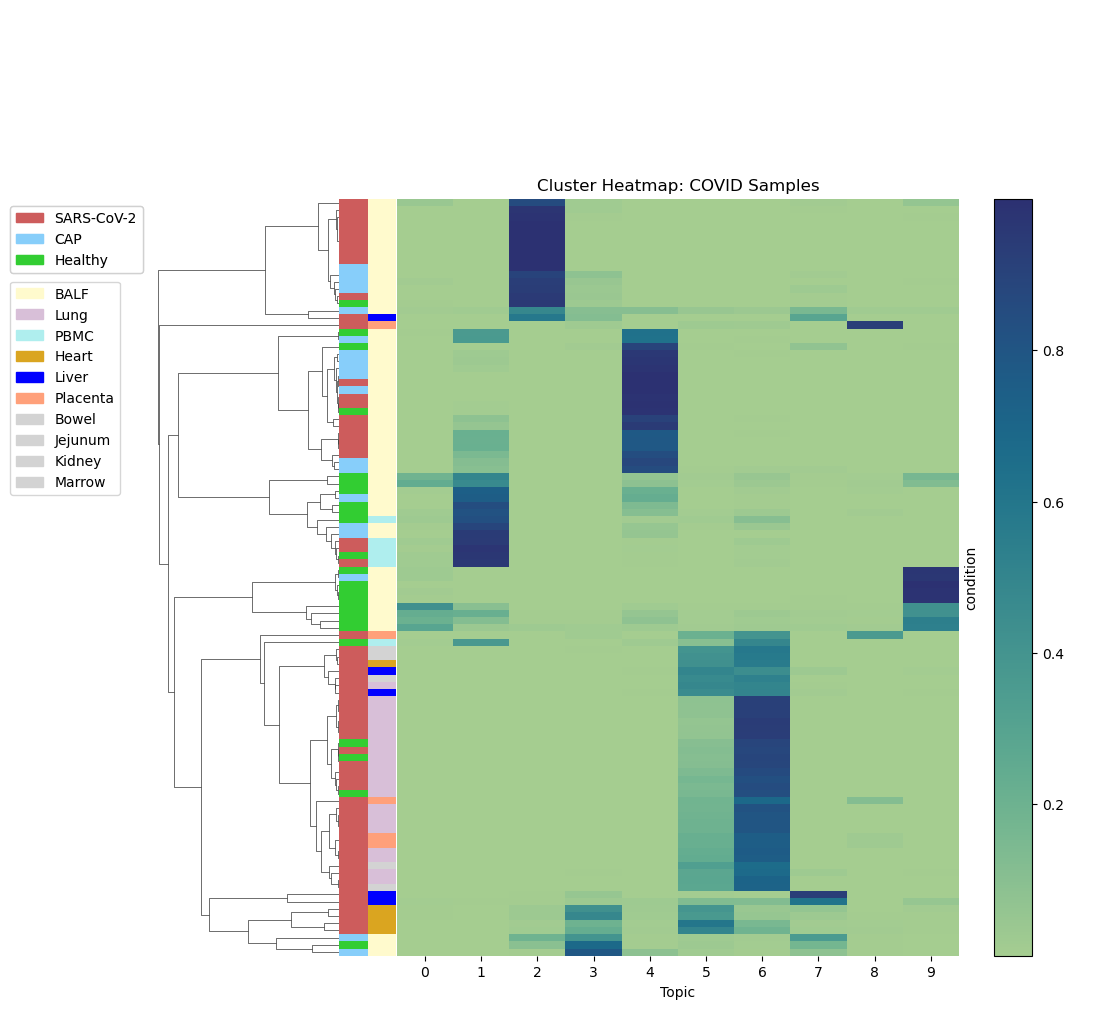

In [11]:
curr_model = load_model(ckpts_covid_t10_a5e2[-1], covid_docSet)
embeds_df = get_embeds(curr_model, covid_docSet) 
embeds_df.index = covid_docSet.samp_metadata['condition']

#Create additional row_colors here
samp_cmap = {'BALF': 'lemonchiffon', 'Lung': 'thistle', 'PBMC': 'paleturquoise', 'Heart':'goldenrod',
             'Liver':'blue', 'Placenta':'lightsalmon', 'Bowel':'lightgrey', 'Jejunum':'lightgrey', 'Kidney':'lightgrey',
             'Marrow':'lightgrey'}
rc_samp = covid_docSet.samp_metadata['tissue'].map(samp_cmap)

cond_cmap = {'SARS-CoV-2': 'indianred', 'CAP':'lightskyblue', 'Healthy':'limegreen'}
rc_cond = covid_docSet.samp_metadata['condition'].map(cond_cmap)

samp_legend = [mpatches.Patch(color=c, label=l) for l, c in samp_cmap.items()]
cond_legend = [mpatches.Patch(color=c, label=l) for l, c in cond_cmap.items()]

g=sns.clustermap(embeds_df, cmap='crest', row_colors=[rc_cond, rc_samp],
                col_cluster=False, yticklabels=False, cbar_pos=None)

plt.colorbar(g.ax_heatmap.get_children()[0], ax=g.ax_heatmap, location='right')

# legend = g.ax_heatmap.legend(loc='center right', bbox_to_anchor=(0.15, 0.5), frameon=True)

l1 = plt.legend(handles=samp_legend, bbox_to_anchor=(-0.7, 0.9), loc='upper left')
plt.gca().add_artist(l1)

l2 = plt.legend(handles=cond_legend, bbox_to_anchor=(-0.7, 1), loc='upper left')
plt.gca().add_artist(l2)

plt.xlabel('Topic')
plt.title('Cluster Heatmap: COVID Samples')
plt.savefig("Cluster_Heatmap_of_COVID.svg")
plt.show()

#### Getting Heatmap for CRC Data

In [8]:
crc_docSet.samp_metadata['tissue'].value_counts()

tissue
Right_colon           30
Rectosigmoid_colon    12
Transverse_colon      12
Sigmoid_colon         10
Cecum                 10
Rectum                 6
Descending_colon       4
Ileum                  2
Colon                  2
Name: count, dtype: int64

In [9]:
crc_docSet.samp_metadata['condition'].value_counts()

condition
tumor     44
normal    44
Name: count, dtype: int64

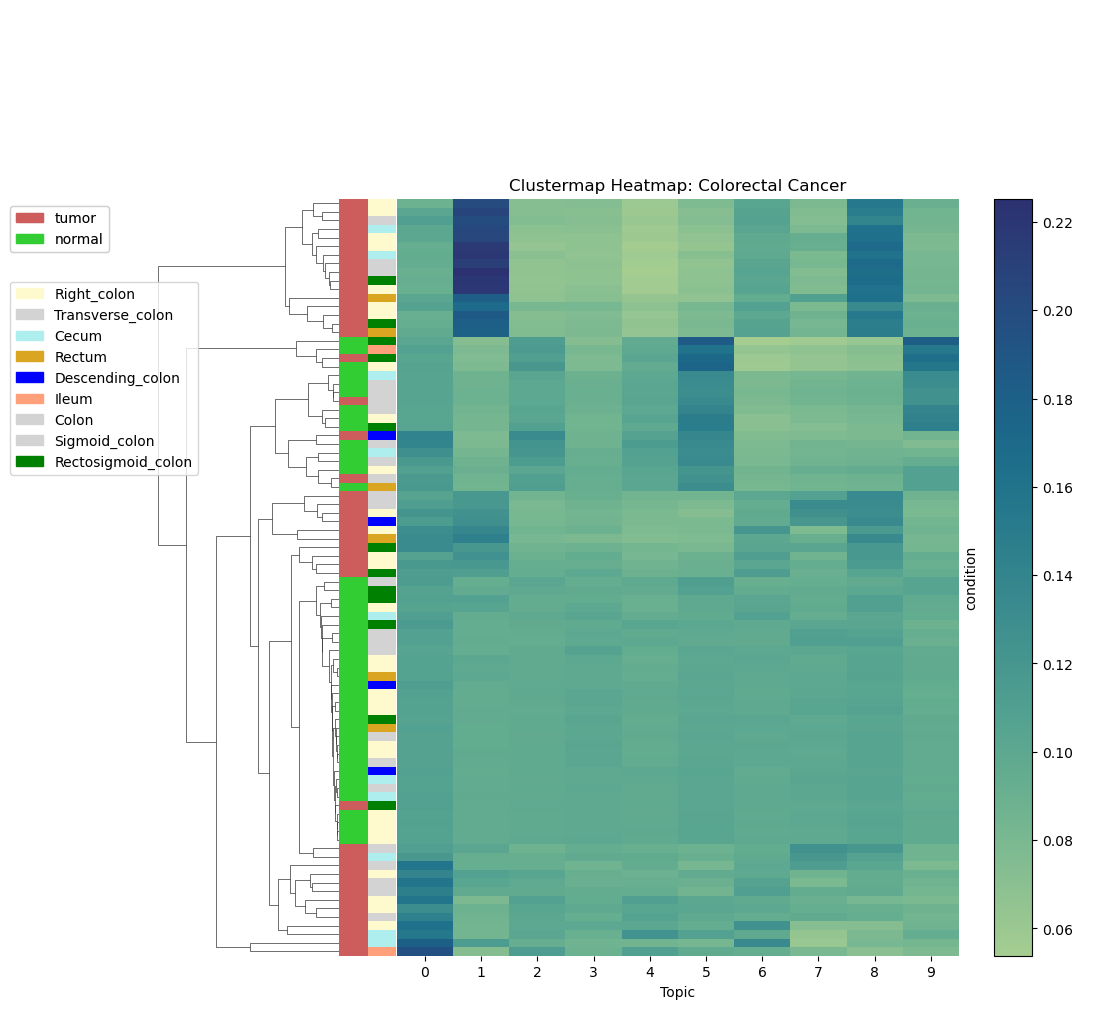

In [12]:
model = load_model(ckpts_crc[-1], crc_docSet)
embeds_df = get_embeds(model, crc_docSet)
embeds_df.index = crc_docSet.samp_metadata['condition']

samp_cmap = {'Right_colon': 'lemonchiffon', 'Transverse_colon': 'lightgrey',
             'Cecum': 'paleturquoise', 'Rectum':'goldenrod',
             'Descending_colon':'blue', 'Ileum':'lightsalmon',
             'Colon':'lightgrey', 'Sigmoid_colon': 'lightgrey',
             'Rectosigmoid_colon':'green'}
rc_samp = crc_docSet.samp_metadata['tissue'].map(samp_cmap)

cond_cmap = {'tumor': 'indianred', 'normal':'limegreen'}
rc_cond = crc_docSet.samp_metadata['condition'].map(cond_cmap)

samp_legend = [mpatches.Patch(color=c, label=l) for l, c in samp_cmap.items()]
cond_legend = [mpatches.Patch(color=c, label=l) for l, c in cond_cmap.items()]

g=sns.clustermap(embeds_df, cmap='crest', row_colors=[rc_cond, rc_samp],
                col_cluster=False, yticklabels=False, cbar_pos=None)

plt.colorbar(g.ax_heatmap.get_children()[0], ax=g.ax_heatmap, location='right')

# legend = g.ax_heatmap.legend(loc='center right', bbox_to_anchor=(0.15, 0.5), frameon=True)

l1 = plt.legend(handles=samp_legend, bbox_to_anchor=(-0.7, 0.9), loc='upper left')
plt.gca().add_artist(l1)

l2 = plt.legend(handles=cond_legend, bbox_to_anchor=(-0.7, 1), loc='upper left')
plt.gca().add_artist(l2)

plt.xlabel('Topic')
plt.title('Clustermap Heatmap: Colorectal Cancer')
plt.savefig("Cluster_Heatmap_of_CRC.svg")
plt.show()

#### Getting heatmap for IBD Data

In [11]:
ibd_docSet.samp_metadata['tissue'].value_counts()

tissue
Rectum              72
Sigmoid Colon        4
Transverse colon     2
Name: count, dtype: int64

In [12]:
ibd_docSet.samp_metadata['condition'].value_counts()

condition
CD        34
UC        22
nonIBD    22
Name: count, dtype: int64

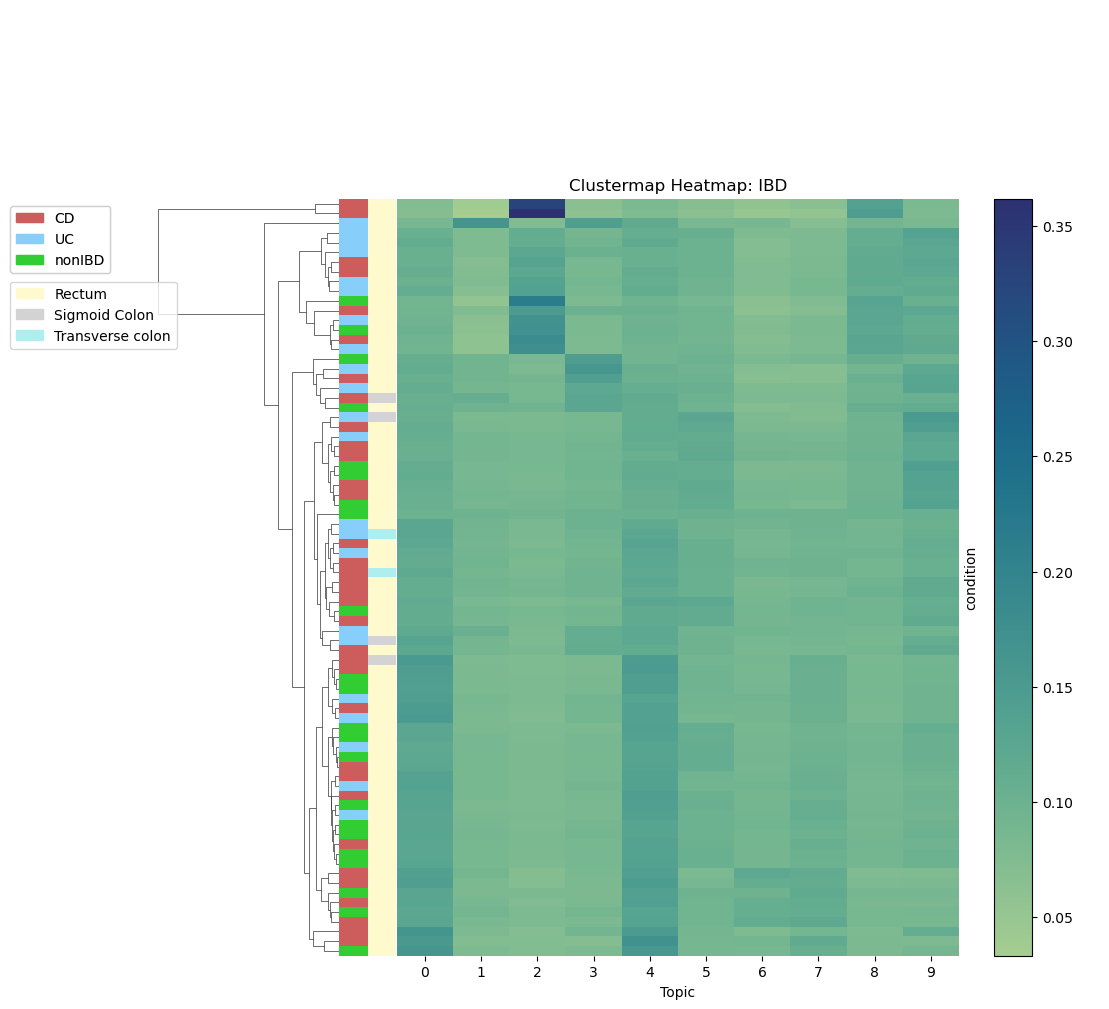

In [16]:
model = load_model(ckpts_ibd_t10_a5e2[-1], ibd_docSet)
embeds_df = get_embeds(model, ibd_docSet)
embeds_df.index = ibd_docSet.samp_metadata['condition']

cond_cmap = {'CD': 'indianred', 'UC':'lightskyblue', 'nonIBD':'limegreen'}
rc_cond = ibd_docSet.samp_metadata['condition'].map(cond_cmap)

samp_cmap = {'Rectum': 'lemonchiffon', 'Sigmoid Colon': 'lightgrey',
             'Transverse colon': 'paleturquoise'}
rc_samp = ibd_docSet.samp_metadata['tissue'].map(samp_cmap)


samp_legend = [mpatches.Patch(color=c, label=l) for l, c in samp_cmap.items()]
cond_legend = [mpatches.Patch(color=c, label=l) for l, c in cond_cmap.items()]

g=sns.clustermap(embeds_df, cmap='crest', row_colors=[rc_cond, rc_samp],
                col_cluster=False, yticklabels=False, cbar_pos=None)

plt.colorbar(g.ax_heatmap.get_children()[0], ax=g.ax_heatmap, location='right')

# legend = g.ax_heatmap.legend(loc='center right', bbox_to_anchor=(0.15, 0.5), frameon=True)

l1 = plt.legend(handles=samp_legend, bbox_to_anchor=(-0.7, 0.9), loc='upper left')
plt.gca().add_artist(l1)

l2 = plt.legend(handles=cond_legend, bbox_to_anchor=(-0.7, 1), loc='upper left')
plt.gca().add_artist(l2)

plt.xlabel('Topic')
plt.title('Clustermap Heatmap: IBD')
plt.savefig("Cluster_Heatmap_of_IBD.svg")
plt.show()

#### Getting Heatmap for IBS Data

In [17]:
ibs_docSet.samp_metadata['condition'].value_counts() # IBS dataset doesn't have tissue origin information

condition
IBS-C      15
IBS-D      14
Healthy    13
Name: count, dtype: int64

In [18]:
model = load_model(ckpts_ibs_t10_a5e2[-1], ibs_docSet)
embeds_df = get_embeds(model, ibs_docSet)
embeds_df.index = ibs_docSet.samp_metadata['condition']
ibs_docSet.samp_metadata['tissue'] = None

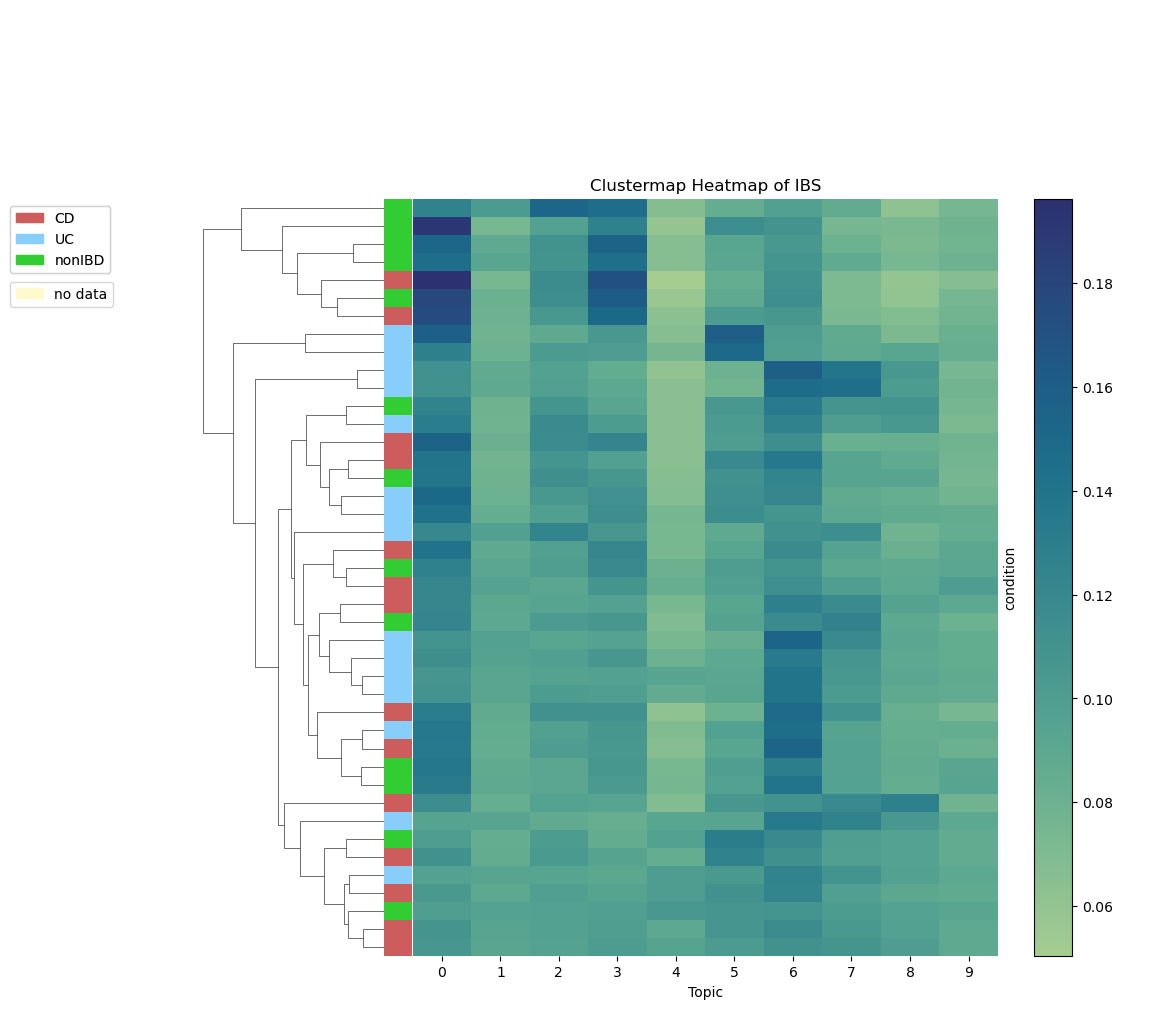

In [19]:
cond_cmap = {'IBS-D': 'indianred', 'IBS-C':'lightskyblue', 'Healthy':'limegreen'}
rc_cond = ibs_docSet.samp_metadata['condition'].map(cond_cmap)

samp_cmap = {'no data': 'lemonchiffon'}
# rc_samp = ibs_docSet.samp_metadata['tissue'].map(samp_cmap)


samp_legend = [mpatches.Patch(color=c, label=l) for l, c in samp_cmap.items()]
# cond_legend = [mpatches.Patch(color=c, label=l) for l, c in cond_cmap.items()]

g=sns.clustermap(embeds_df, cmap='crest', row_colors=[rc_cond],
                col_cluster=False, yticklabels=False, cbar_pos=None)

plt.colorbar(g.ax_heatmap.get_children()[0], ax=g.ax_heatmap, location='right')

# legend = g.ax_heatmap.legend(loc='center right', bbox_to_anchor=(0.15, 0.5), frameon=True)

l1 = plt.legend(handles=samp_legend, bbox_to_anchor=(-0.7, 0.9), loc='upper left')
plt.gca().add_artist(l1)

l2 = plt.legend(handles=cond_legend, bbox_to_anchor=(-0.7, 1), loc='upper left')
plt.gca().add_artist(l2)

plt.xlabel('Topic')
plt.title('Clustermap Heatmap of IBS')
plt.savefig("Cluster_Heatmap_of_IBS.svg")
plt.show()